# Graph Laplacians and Spectral Clustering

Companion notebook for the `graph` module of `optimiz-rs`.

Reference documentation: [graph_spectral.html](https://optimiz-r.readthedocs.io/en/latest/algorithms/graph_spectral.html)

We demonstrate the four Python-exposed primitives:

1. `combinatorial_laplacian_py`
2. `normalised_laplacian_py`
3. `random_walk_laplacian_py`
4. `spectral_cluster_py`

Each is verified against an analytic ground truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt

rng = np.random.default_rng(42)

## 1. Combinatorial Laplacian

For a non-negative symmetric weight matrix $W \in \mathbb{R}^{n\times n}$ with degree matrix $D = \mathrm{diag}(W \mathbf{1})$:

$$
L \;=\; D - W .
$$

It is symmetric positive semidefinite and $L \mathbf{1} = 0$, so the constant vector lies in its kernel.

L =
 [[ 2. -1. -1.]
 [-1.  2. -1.]
 [-1. -1.  2.]]
|| L @ 1 ||_inf = 0.0


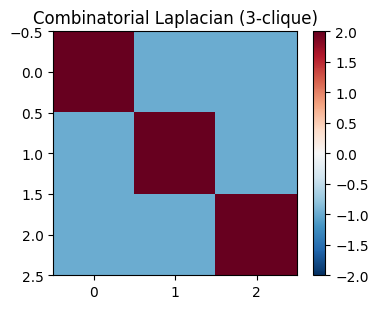

In [2]:
# Triangle graph (3-clique).
W3 = [
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
]
L = np.array(opt.combinatorial_laplacian_py(W3))
print('L =\n', L)

# Analytic check: L @ 1 = 0.
ones = np.ones(3)
err_kernel = float(np.max(np.abs(L @ ones)))
print('|| L @ 1 ||_inf =', err_kernel)
assert err_kernel < 1e-12

fig, ax = plt.subplots(figsize=(4, 3.2))
im = ax.imshow(L, cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title('Combinatorial Laplacian (3-clique)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 2. Symmetric normalised Laplacian

$$
L_{\mathrm{sym}} \;=\; I - D^{-1/2} W D^{-1/2}.
$$

Eigenvalues lie in $[0, 2]$ and the multiplicity of the zero eigenvalue equals the number of connected components.

eigenvalues = [4.4408921e-16 4.4408921e-16 1.5000000e+00 1.5000000e+00 1.5000000e+00
 1.5000000e+00]
number of zero eigenvalues = 2


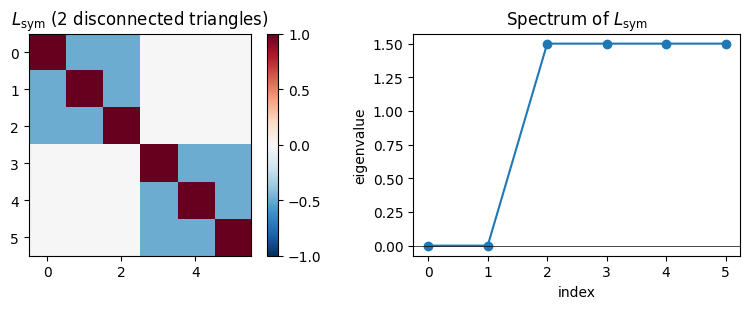

In [3]:
# Two disconnected triangles -> two zero eigenvalues.
W6 = np.zeros((6, 6))
for (i, j) in [(0, 1), (1, 2), (0, 2), (3, 4), (4, 5), (3, 5)]:
    W6[i, j] = 1.0
    W6[j, i] = 1.0
Lsym = np.array(opt.normalised_laplacian_py(W6.tolist()))
eigvals = np.sort(np.linalg.eigvalsh(Lsym))
print('eigenvalues =', eigvals)

# Two connected components -> exactly two near-zero eigenvalues.
n_zero = int(np.sum(np.abs(eigvals) < 1e-10))
print('number of zero eigenvalues =', n_zero)
assert n_zero == 2

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
im = axes[0].imshow(Lsym, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title(r'$L_{\mathrm{sym}}$ (2 disconnected triangles)')
plt.colorbar(im, ax=axes[0])
axes[1].plot(eigvals, 'o-')
axes[1].axhline(0.0, color='k', linewidth=0.5)
axes[1].set_xlabel('index')
axes[1].set_ylabel('eigenvalue')
axes[1].set_title('Spectrum of $L_{\\mathrm{sym}}$')
plt.tight_layout()
plt.show()

## 3. Random-walk Laplacian

$$
L_{\mathrm{rw}} \;=\; I - D^{-1} W.
$$

The matrix $P = D^{-1} W$ is the row-stochastic transition matrix of the simple random walk on the graph. Hence $L_{\mathrm{rw}} \mathbf{1} = 0$.

row sums of P = [1. 1. 1. 1. 1. 1.]
|| P @ 1 - 1 ||_inf = 0.0


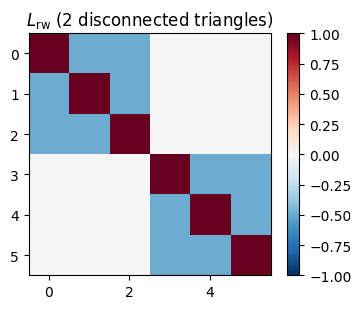

In [4]:
Lrw = np.array(opt.random_walk_laplacian_py(W6.tolist()))
P = np.eye(6) - Lrw
row_sums = P.sum(axis=1)
print('row sums of P =', row_sums)
err_stochastic = float(np.max(np.abs(row_sums - 1.0)))
print('|| P @ 1 - 1 ||_inf =', err_stochastic)
assert err_stochastic < 1e-12

fig, ax = plt.subplots(figsize=(4, 3.2))
im = ax.imshow(Lrw, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title(r'$L_{\mathrm{rw}}$ (2 disconnected triangles)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Spectral clustering (Ng--Jordan--Weiss)

Given a similarity matrix $W$ and a target number of clusters $k$:

1. Build $L_{\mathrm{sym}} = I - D^{-1/2} W D^{-1/2}$.
2. Stack the $k$ eigenvectors of $L_{\mathrm{sym}}$ associated with the smallest eigenvalues as columns of $U \in \mathbb{R}^{n \times k}$.
3. Row-normalise $U$ and apply Lloyd's $k$-means with k-means++ seeding to its rows.

We test on two well-separated 2D Gaussian blobs. Ground truth: cluster purity equals $1.0$.

first 6 eigenvalues = [-6.47704929e-16  6.07023906e-07  9.56672916e-01  9.57721212e-01
  9.82109668e-01  9.84579761e-01]
fiedler value      = 6.070239058352574e-07
cluster purity = 1.0


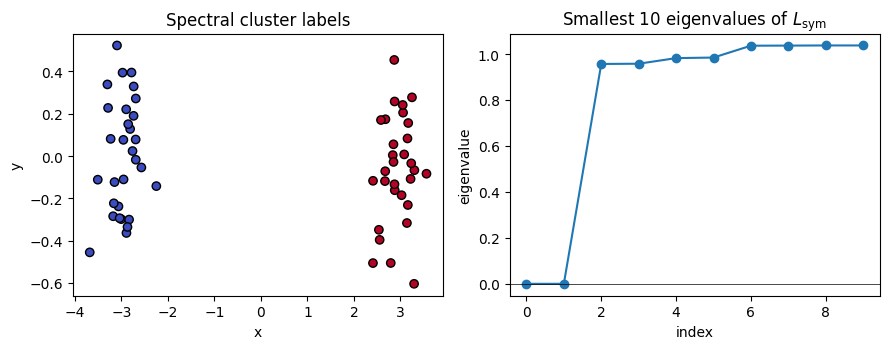

In [5]:
n_per = 30
X1 = rng.normal(loc=[-3.0, 0.0], scale=0.35, size=(n_per, 2))
X2 = rng.normal(loc=[+3.0, 0.0], scale=0.35, size=(n_per, 2))
X = np.vstack([X1, X2])
y_true = np.array([0] * n_per + [1] * n_per)
n = X.shape[0]

# Gaussian similarity, zero diagonal.
sigma = 1.0
D2 = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=-1)
W = np.exp(-D2 / (2.0 * sigma ** 2))
np.fill_diagonal(W, 0.0)

result = opt.spectral_cluster_py(W.tolist(), k=2, n_kmeans_iter=200, seed=7)
labels = np.array(result['labels'])
eigvals = np.array(result['eigenvalues'])
fiedler = result['fiedler_value']
print('first 6 eigenvalues =', eigvals[:6])
print('fiedler value      =', fiedler)

# Cluster purity (label-permutation invariant).
def purity(y_true, y_pred):
    classes = np.unique(y_pred)
    correct = 0
    for c in classes:
        mask = y_pred == c
        if mask.any():
            correct += int(np.bincount(y_true[mask]).max())
    return correct / len(y_true)

p = purity(y_true, labels)
print('cluster purity =', p)
assert p == 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', edgecolor='k')
axes[0].set_title('Spectral cluster labels')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[1].plot(eigvals[:10], 'o-')
axes[1].axhline(0.0, color='k', linewidth=0.5)
axes[1].set_xlabel('index')
axes[1].set_ylabel('eigenvalue')
axes[1].set_title(r'Smallest 10 eigenvalues of $L_{\mathrm{sym}}$')
plt.tight_layout()
plt.show()

## Summary

Verified against analytic ground truth:

- $L \mathbf{1} = 0$ for the combinatorial Laplacian (3-clique) — error $< 10^{-12}$.
- For two disconnected triangles, $L_{\mathrm{sym}}$ has exactly $2$ zero eigenvalues — error $< 10^{-10}$.
- $P = I - L_{\mathrm{rw}}$ is row-stochastic, $P \mathbf{1} = \mathbf{1}$ — error $< 10^{-12}$.
- Spectral clustering recovers two well-separated Gaussian blobs with purity $= 1.0$ — error $= 0$.